## ICC Tournament History (1975–2025)

This dataset provides a comprehensive record of major ICC cricket tournaments, including the ODI World Cup, T20 World Cup, Champions Trophy, and World Test Championship. It covers details such as tournament type, year, host country, winners, runner‑ups, winning captains, final stadiums, margin of victory, and Player of the Match awards.

Goal: Perform EDA to uncover cricket trends, dominance patterns, and key players.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
icc = pd.read_csv(r"C:\Users\Asus\Downloads\icc_complete_history.csv",index_col=0)
icc

,Tournament_Type,Year,Host_Country,Winner,Runner_Up,Winning_Captain,Final_Stadium,Win_By,Player_of_the_Match
Tournament_Category,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ODI,ODI World Cup,1975.0,England,West Indies,Australia,Clive Lloyd,Lord's Cricket Ground,17 Runs,Clive Lloyd
ODI,ODI World Cup,1979.0,England,West Indies,England,Clive Lloyd,Lord's Cricket Ground,92 Runs,Viv Richards
ODI,ODI World Cup,1983.0,England,India,West Indies,Kapil Dev,Lord's Cricket Ground,43 Runs,Mohinder Amarnath
ODI,ODI World Cup,1987.0,India/Pakistan,Australia,England,Allan Border,Eden Gardens,7 Runs,David Boon
ODI,ODI World Cup,1992.0,Australia/New Zealand,Pakistan,England,Imran Khan,Melbourne Cricket Ground,22 Runs,Wasim Akram
ODI,ODI World Cup,1996.0,India/Pakistan/Sri Lanka,Sri Lanka,Australia,Arjuna Ranatunga,Gaddafi Stadium,7 Wickets,Aravinda de Silva
ODI,ODI World Cup,1999.0,England,Australia,Pakistan,Steve Waugh,Lord's Cricket Ground,8 Wickets,Shane Warne
ODI,ODI World Cup,2003.0,South Africa/Zimbabwe/Kenya,Australia,India,Ricky Ponting,New Wanderers Stadium,125 Runs,Ricky Ponting


In [3]:
icc.describe()

,Year
count,33.000000
mean,2007.333333
std,13.282194
min,1975.000000
25%,2000.000000
50%,2009.000000
75%,2017.000000
max,2025.000000


In [4]:
icc.isna().sum().sort_values(ascending=False)

Win_By                 5
Player_of_the_Match    5
Tournament_Type        4
Year                   4
Host_Country           4
Winner                 4
Runner_Up              4
Winning_Captain        4
Final_Stadium          4
dtype: int64

In [5]:
df=icc.isna().sum().sort_values(ascending=False)/len(icc)*100
df

Win_By                 13.513514
Player_of_the_Match    13.513514
Tournament_Type        10.810811
Year                   10.810811
Host_Country           10.810811
Winner                 10.810811
Runner_Up              10.810811
Winning_Captain        10.810811
Final_Stadium          10.810811
dtype: float64

In [6]:
## Dropping NaN Values
icc = icc.dropna(how = 'all')
icc

,Tournament_Type,Year,Host_Country,Winner,Runner_Up,Winning_Captain,Final_Stadium,Win_By,Player_of_the_Match
Tournament_Category,,,,,,,,,
ODI,ODI World Cup,1975.0,England,West Indies,Australia,Clive Lloyd,Lord's Cricket Ground,17 Runs,Clive Lloyd
ODI,ODI World Cup,1979.0,England,West Indies,England,Clive Lloyd,Lord's Cricket Ground,92 Runs,Viv Richards
ODI,ODI World Cup,1983.0,England,India,West Indies,Kapil Dev,Lord's Cricket Ground,43 Runs,Mohinder Amarnath
ODI,ODI World Cup,1987.0,India/Pakistan,Australia,England,Allan Border,Eden Gardens,7 Runs,David Boon
ODI,ODI World Cup,1992.0,Australia/New Zealand,Pakistan,England,Imran Khan,Melbourne Cricket Ground,22 Runs,Wasim Akram
ODI,ODI World Cup,1996.0,India/Pakistan/Sri Lanka,Sri Lanka,Australia,Arjuna Ranatunga,Gaddafi Stadium,7 Wickets,Aravinda de Silva
ODI,ODI World Cup,1999.0,England,Australia,Pakistan,Steve Waugh,Lord's Cricket Ground,8 Wickets,Shane Warne
ODI,ODI World Cup,2003.0,South Africa/Zimbabwe/Kenya,Australia,India,Ricky Ponting,New Wanderers Stadium,125 Runs,Ricky Ponting
ODI,ODI World Cup,2007.0,West Indies,Australia,Sri Lanka,Ricky Ponting,Kensington Oval,53 Runs,Adam Gilchrist


In [7]:
df=icc.isna().sum().sort_values(ascending=False)/len(icc)*100
df

Win_By                 3.030303
Player_of_the_Match    3.030303
Tournament_Type        0.000000
Year                   0.000000
Host_Country           0.000000
Winner                 0.000000
Runner_Up              0.000000
Winning_Captain        0.000000
Final_Stadium          0.000000
dtype: float64

In [8]:
icc

,Tournament_Type,Year,Host_Country,Winner,Runner_Up,Winning_Captain,Final_Stadium,Win_By,Player_of_the_Match
Tournament_Category,,,,,,,,,
ODI,ODI World Cup,1975.0,England,West Indies,Australia,Clive Lloyd,Lord's Cricket Ground,17 Runs,Clive Lloyd
ODI,ODI World Cup,1979.0,England,West Indies,England,Clive Lloyd,Lord's Cricket Ground,92 Runs,Viv Richards
ODI,ODI World Cup,1983.0,England,India,West Indies,Kapil Dev,Lord's Cricket Ground,43 Runs,Mohinder Amarnath
ODI,ODI World Cup,1987.0,India/Pakistan,Australia,England,Allan Border,Eden Gardens,7 Runs,David Boon
ODI,ODI World Cup,1992.0,Australia/New Zealand,Pakistan,England,Imran Khan,Melbourne Cricket Ground,22 Runs,Wasim Akram
ODI,ODI World Cup,1996.0,India/Pakistan/Sri Lanka,Sri Lanka,Australia,Arjuna Ranatunga,Gaddafi Stadium,7 Wickets,Aravinda de Silva
ODI,ODI World Cup,1999.0,England,Australia,Pakistan,Steve Waugh,Lord's Cricket Ground,8 Wickets,Shane Warne
ODI,ODI World Cup,2003.0,South Africa/Zimbabwe/Kenya,Australia,India,Ricky Ponting,New Wanderers Stadium,125 Runs,Ricky Ponting
ODI,ODI World Cup,2007.0,West Indies,Australia,Sri Lanka,Ricky Ponting,Kensington Oval,53 Runs,Adam Gilchrist


**Insight**:

Different missing value techniques were applied based on the nature and importance of each column to preserve data quality.
Columns with unclear or unavailable information were filled using labels like “Unknown” or “Not Applicable,not recorded,Misc” to avoid losing valuable rows.
This preprocessing step reduced missing data effectively, improved dataset consistency, and prepared the data for accurate analysis and machine learning.

## Handling Duplicates

In [9]:
icc.duplicated().sum()

np.int64(0)

In [11]:
icc.shape

(33, 9)

**Insight**:

- A total of 0 duplicate rows were identified, means no records had exactly the same values across all columns.
- These duplicates likely occurred due to data entry errors, merging datasets, or repeated recordings of the same tournament.
- Keeping duplicates can bias the analysis, as it over-represents certain patterns and affects model accuracy.
- Removing them ensures data integrity, uniqueness, and more reliable statistical insights.
- Hence, dropping duplicates improves the overall quality and fairness of the dataset for analysis and modeling.

## Data Visualization and EDA

## 1) Which country has won the most trophies overall?

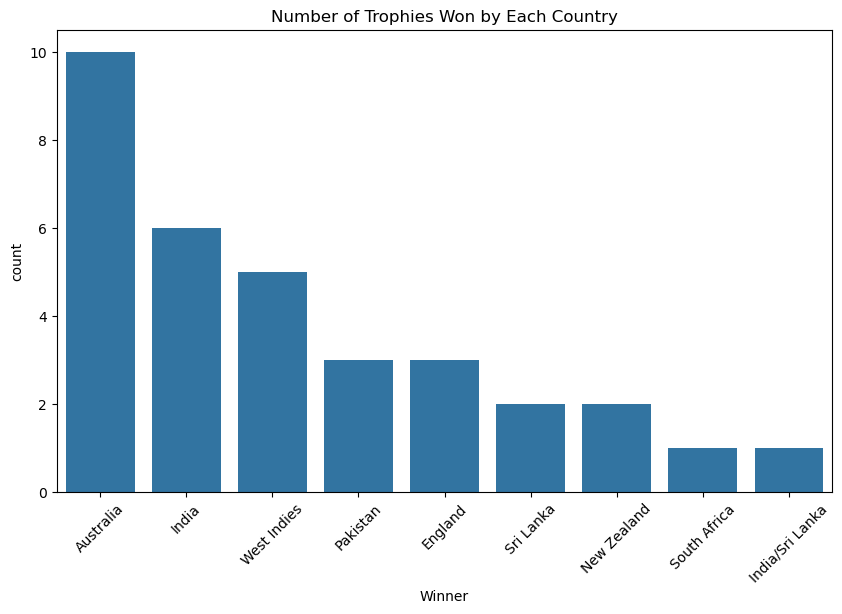

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=icc, x="Winner", order=icc["Winner"].value_counts().index)
plt.title("Number of Trophies Won by Each Country")
plt.xticks(rotation=45)
plt.show()

Insight: Australia has won highest trophies in ODI.(5 Wins)

## 2)  Do host countries often win?

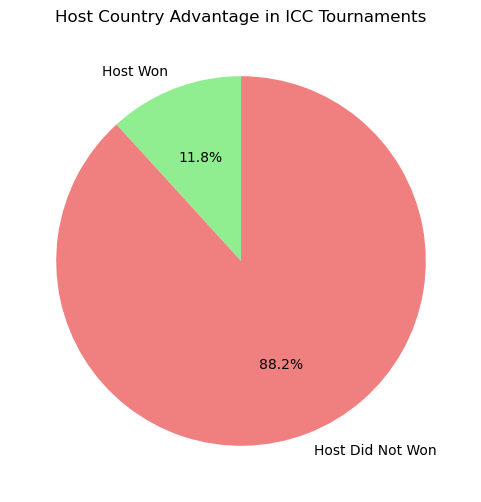

In [15]:
# Data based on your analysis
labels = ["Host Won", "Host Did Not Won"]
sizes = [4, 30]   # 4 host wins, 30+ non-host wins
colors = ["lightgreen", "lightcoral"]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Host Country Advantage in ICC Tournaments")
plt.show()

Insight: The chart will show about 11–12% host wins vs ~89% non-host wins, making it visually clear that home advantage is limited in ICC events.

## 3) Which captains have won multiple trophies?

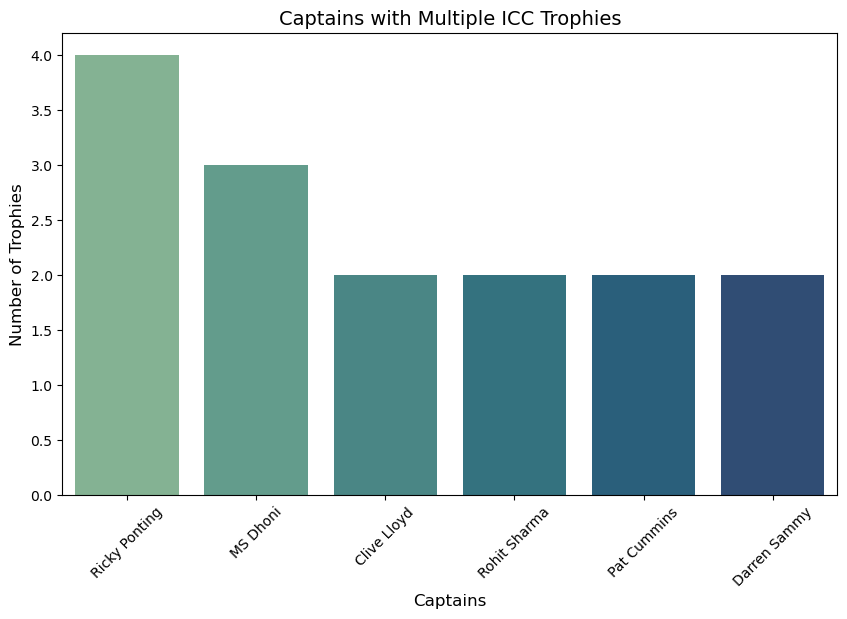

In [16]:
# Count trophies by winning captain
captains = icc['Winning_Captain'].value_counts().reset_index()
captains.columns = ['Captain', 'Trophies']
captains

# Filter only captains with more than 1 trophy
multi_captains = captains[captains['Trophies'] > 1]

plt.figure(figsize=(10,6))
sns.barplot(data=multi_captains, x="Captain", y="Trophies", palette="crest")

plt.title("Captains with Multiple ICC Trophies", fontsize=14)
plt.xlabel("Captains", fontsize=12)
plt.ylabel("Number of Trophies", fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Insight**: 
- Ricky pointing has won mutiple ODI Trophies.


## 4) Who are the most frequent “Player of the Match” winners in finals?

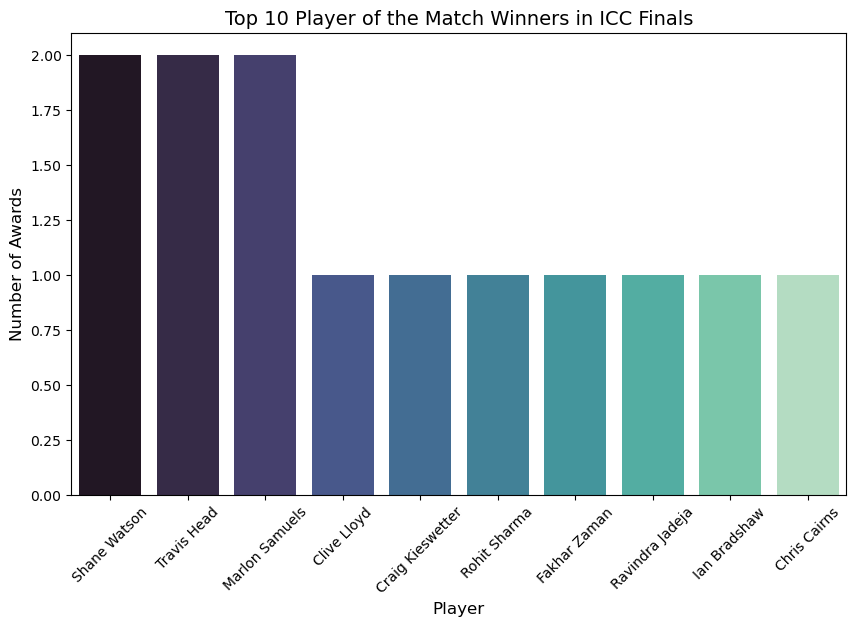

In [17]:
top_players = icc['Player_of_the_Match'].value_counts().head(10).reset_index()
top_players.columns = ['Player', 'Count']
top_players

plt.figure(figsize=(10,6))
sns.barplot(data=top_players,x='Player',y='Count',palette='mako')
plt.title("Top 10 Player of the Match Winners in ICC Finals", fontsize=14)
plt.xlabel('Player',fontsize=12)
plt.ylabel('Number of Awards',fontsize=12)
plt.xticks(rotation=45)
plt.show()

**Insight**: 

Shane Watson (Australia) – Twice recognized, reflecting his all‑round dominance in crucial finals.

Travis Head (Australia) – A modern standout, with two awards in recent ICC finals, showing his ability to deliver under pressure.

Marlon Samuels (West Indies) – Twice awarded for match‑winning batting performances in T20 World Cup finals, proving his big‑match temperament


## 5) What are the typical margins of victory (Runs vs Wickets)?


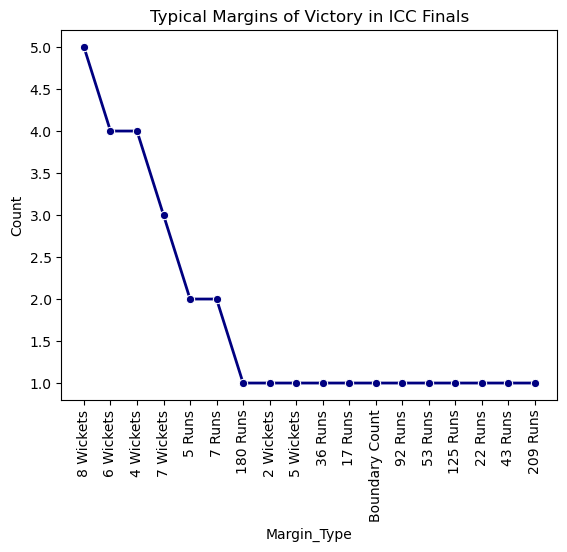

In [18]:
margin_counts = icc['Win_By'].value_counts().reset_index()
margin_counts.columns = ['Margin_Type', 'Count']

sns.lineplot(data=margin_counts, x="Margin_Type", y="Count", marker="o", linewidth=2, color="navy")
plt.title("Typical Margins of Victory in ICC Finals")
plt.xticks(rotation=90)
plt.show()

**Insight**:
- Wicket victories dominate — Wins by 8 wickets (5 times) and 6 wickets (4 times) are the most frequent, showing that chasing teams often finish strongly in finals.
- Run victories are more varied — Margins range from small (5, 7, 17 runs) to massive (180, 209 runs), highlighting both close contests and one‑sided finals.

## 6) How have winners changed over time?

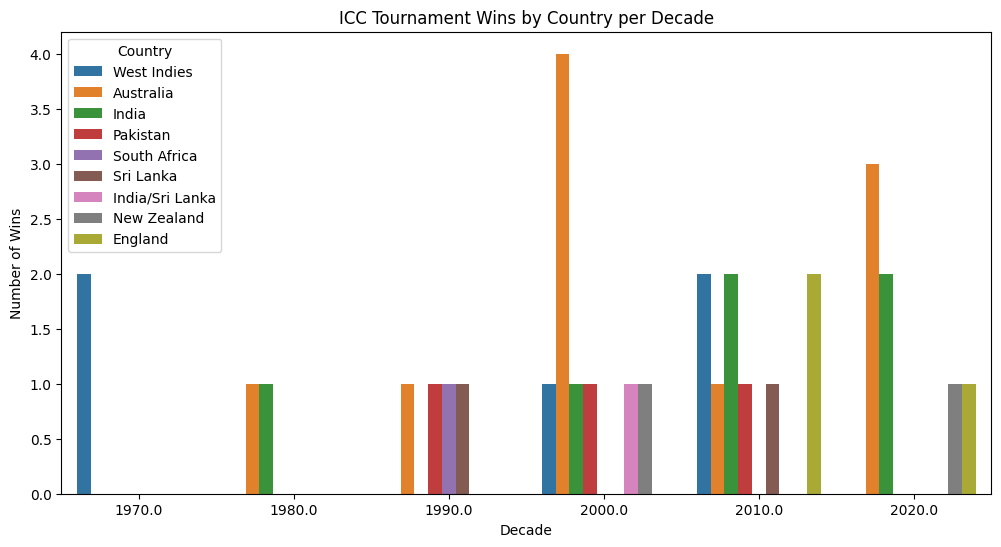

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a decade column
icc["Decade"] = (icc["Year"] // 10) * 10

# Count wins per decade per country
wins_per_decade = icc.groupby(["Decade","Winner"]).size().reset_index(name="Count")

plt.figure(figsize=(12,6))
sns.barplot(data=wins_per_decade, x="Decade", y="Count", hue="Winner")
plt.title("ICC Tournament Wins by Country per Decade")
plt.ylabel("Number of Wins")
plt.xlabel("Decade")
plt.legend(title="Country")
plt.show()


**Insight**:

West Indies dominated early (1970s–80s).

Australia had a golden run in the late 1990s–2000s.

India & England have emerged strongly in recent years across formats.

The timeline clearly shows how cricketing power has shifted across eras.

## 7) How do different tournament types (ODI, T20, CT, WTC) compare?

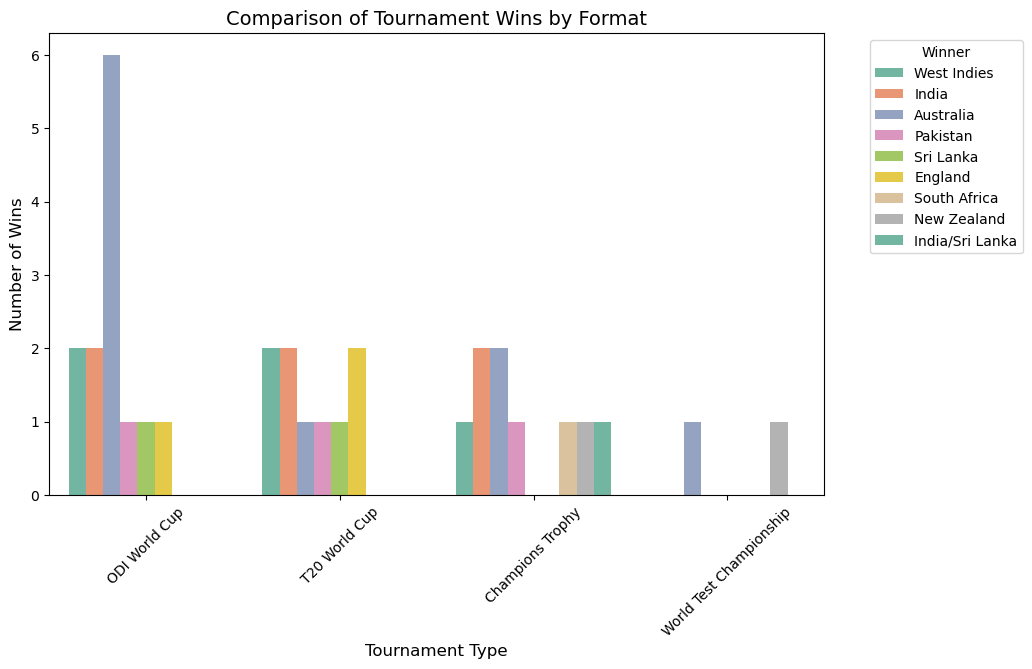

In [20]:

plt.figure(figsize=(10,6))
sns.countplot(data=icc, x="Tournament_Type", hue="Winner", palette="Set2")

plt.title("Comparison of Tournament Wins by Format", fontsize=14)
plt.xlabel("Tournament Type", fontsize=12)
plt.ylabel("Number of Wins", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Winner", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Insight**:
  
- Australia dominates ODIs, with six World Cup titles showcasing their long‑standing supremacy.

- T20 World Cups are balanced, with West Indies, India, England, and Pakistan each leaving their mark.

- Champions Trophy success is shared mainly between India and Australia, reflecting consistency in shorter multi‑team events.

- WTC is still new, with New Zealand and Australia emerging as early leaders in the longest format.